In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

import random

import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_data.csv")
df.head()

,Operator,Batch,Column Name,0,1,2,3,4,5,6,...,281,282,283,284,285,286,287,288,289,290
0,Dauda,B,Blank 1,4.034531,4.074168,4.146334,4.776366,5.166968,5.380499,5.783000,...,2.337577,2.020427,1.975400,1.941748,1.633529,1.988009,1.735568,1.785770,1.741221,1.557681
1,Dauda,B,Blank 2,3.721135,4.139870,4.224371,4.480368,4.970104,5.373269,5.696165,...,2.100548,1.887893,2.019797,1.933458,1.834948,1.688483,1.707889,1.607058,1.610973,1.564751
2,Dauda,B,Blank 3,3.855386,4.070697,4.404411,4.415771,5.035495,5.213314,5.727901,...,2.106403,1.978239,2.042932,1.974319,1.896538,1.892534,1.729521,1.757066,1.565516,1.317423
3,Dauda,B,Blank 4,3.942278,3.979981,3.998706,4.489305,4.952526,5.269382,5.740615,...,2.118773,1.842209,1.912104,2.033359,1.760132,1.929425,1.586962,1.660446,1.618268,1.553990
4,Dauda,B,Blank 5,3.881226,3.961999,4.318709,4.769429,5.028099,5.504888,5.690028,...,2.223238,2.114036,2.101678,1.993529,2.018873,1.755243,1.678757,1.772566,1.536214,1.497676


In [3]:
df['Operator'] = df['Operator'].map({'Dauda': 0, 'Aidan': 1, 'JD': 2, 'Muizat': 3})
df['Batch'] = df['Batch'].map({'B': 0, 'D': 1, 'E' : 2})

In [4]:
X = df.drop('Column Name', axis=1)
y = df['Column Name']

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = X_scaled[:,2:]
print(X_scaled[:2])

[[ 0.29592679  0.29934702  0.26913721  0.53482915  0.66154037  0.67438525
   0.79224392  0.9976843   0.96980246  0.89326822  1.0653976   1.08212134
   1.00844181  1.06713866  0.94468882  1.0406697   1.18065717  1.11014528
   1.17799685  1.13885745  1.34869475  1.20685851  1.34404364  1.35580837
   1.34241214  1.3803854   1.42756708  1.52326888  1.50529388  1.46013938
   1.59362222  1.62501251  1.55303772  1.5781112   1.59726394  1.59474363
   1.65509583  1.6542948   1.64761405  1.62207908  1.62268156  1.6002167
   1.60448982  1.54564243  1.57981934  1.56938385  1.58177958  1.56835254
   1.53553238  1.55385851  1.53599799  1.5463811   1.53724391  1.56602631
   1.53477797  1.53990672  1.54019429  1.53237521  1.52951945  1.50078174
   1.4981988   1.51959989  1.50651161  1.48162108  1.49282139  1.49694026
   1.48410796  1.48317217  1.49573764  1.46889184  1.48093804  1.49626794
   1.4932085   1.48545288  1.48312863  1.46600512  1.47990015  1.49827118
   1.46631936  1.50080648  1.49542191  

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(np.cumsum(pca.explained_variance_ratio_)) # 91.4% - first 2 components

[0.68979259 0.913926  ]


In [7]:
np.unique(y)

array(['100pM PFOA 1', '100pM PFOA 2', '100pM PFOA 3', '100pM PFOA 4',
       '100pM PFOA 5', '100pM PFOA 6', '100pM PFOA 7', '200pM PFOA 1',
       '200pM PFOA 2', '200pM PFOA 3', '200pM PFOA 4', '200pM PFOA 5',
       '200pM PFOA 6', '200pM PFOA 7', '800pM PFOA 1', '800pM PFOA 2',
       '800pM PFOA 3', '800pM PFOA 4', '800pM PFOA 5', '800pM PFOA 6',
       '800pM PFOA 7', 'Blank 1', 'Blank 2', 'Blank 3', 'Blank 4',
       'Blank 5', 'Blank 6', 'Blank 7'], dtype=object)

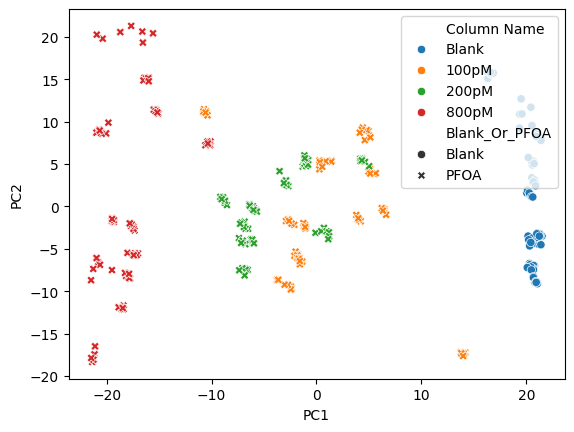

In [8]:
def perform_PCA(subset):
    concentration = subset["Column Name"].str.split(" ").str[0] # concentration
    subset["Concentration"] = concentration

    subset["Blank_Or_PFOA"] = np.where(subset["Concentration"].str.contains("Blank"), "Blank", "PFOA")

    pca_df = subset
    pca_df["PC1"] = X_pca[:, 0]
    pca_df["PC2"] = X_pca[:, 1]
    
    sns.scatterplot(data = pca_df, x = "PC1", y = "PC2", hue = concentration, style=subset["Blank_Or_PFOA"])

perform_PCA(df)

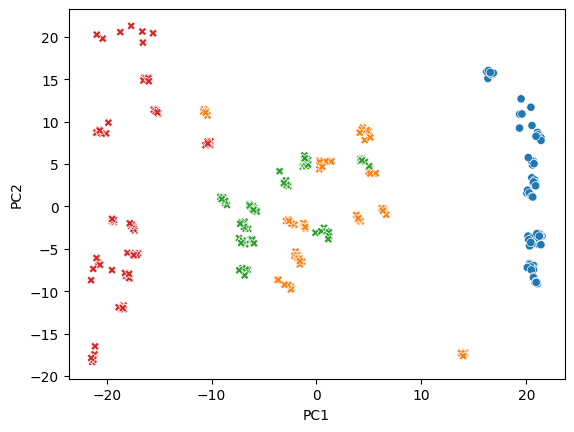

In [9]:
def PCA_no_legend(subset):
    concentration = subset["Column Name"].str.split(" ").str[0] # concentration
    subset["Concentration"] = concentration

    subset["Blank_Or_PFOA"] = np.where(subset["Concentration"].str.contains("Blank"), "Blank", "PFOA")

    pca_df = subset
    pca_df["PC1"] = X_pca[:, 0]
    pca_df["PC2"] = X_pca[:, 1]
    
    sns.scatterplot(data = pca_df, x = "PC1", y = "PC2", hue = concentration, style=subset["Blank_Or_PFOA"], legend = False) # removed legend

PCA_no_legend(df)